Correlación entre xx_ruido y nq: 0.0226


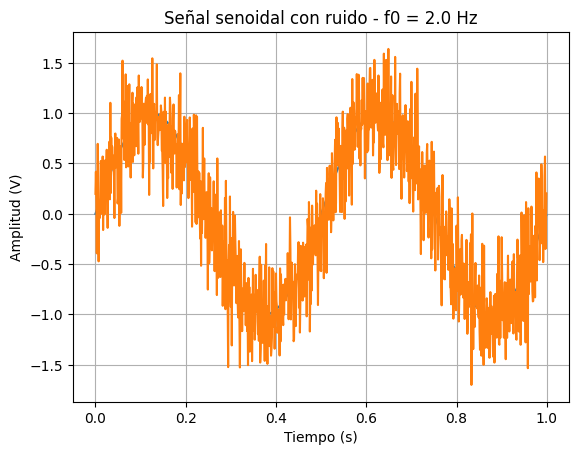

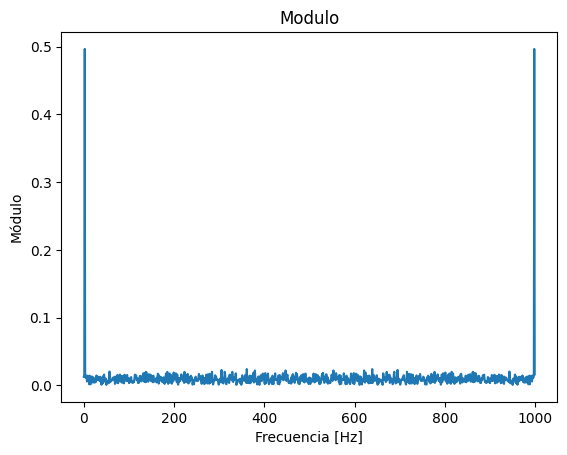

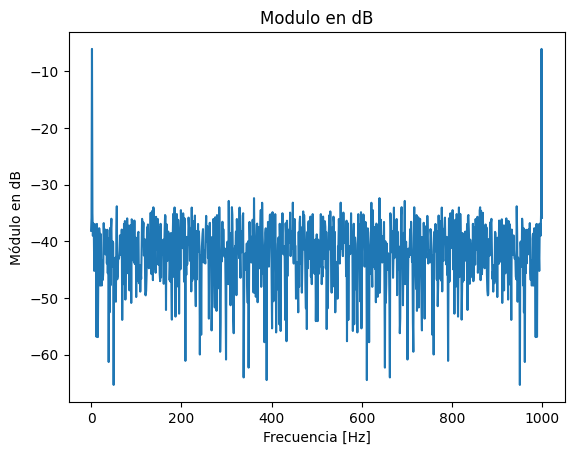

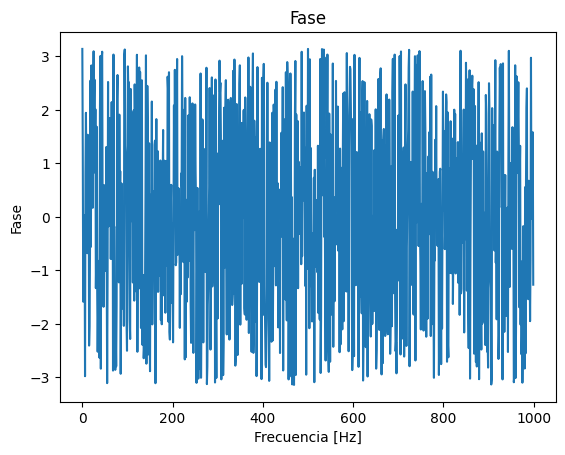

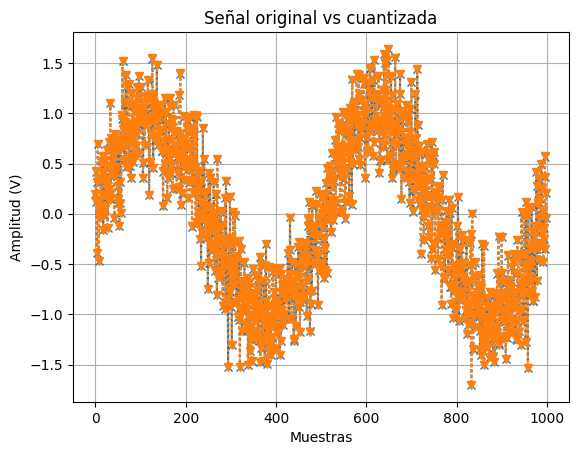

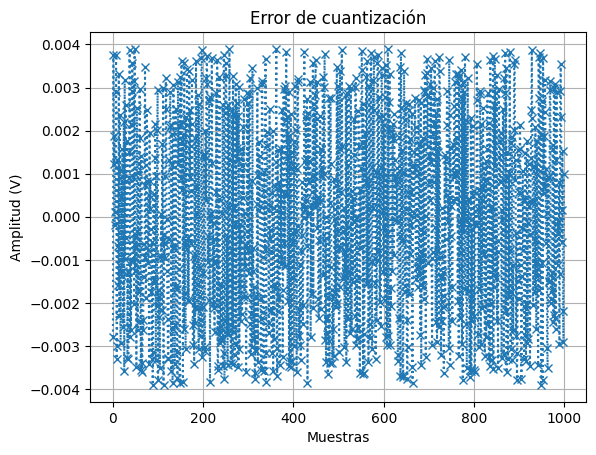

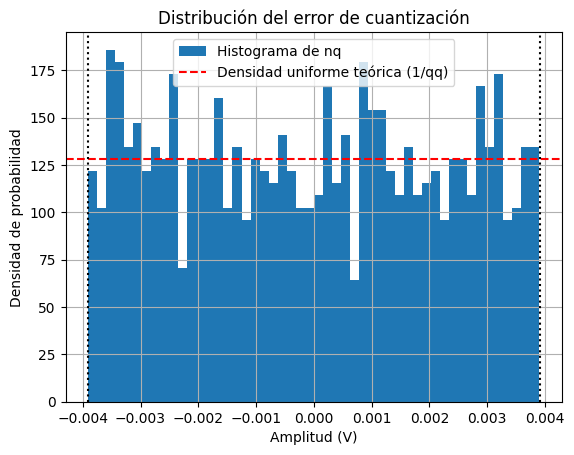

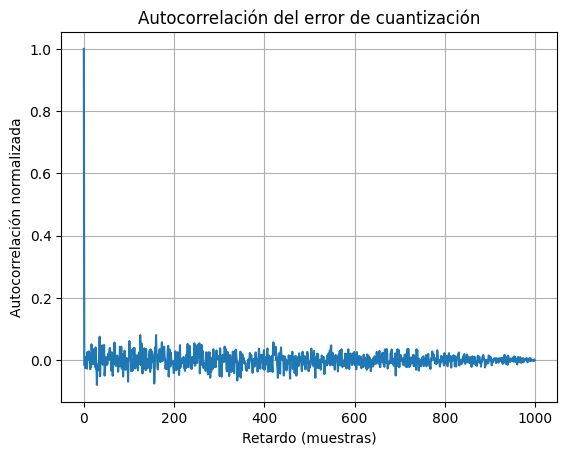

In [1]:
import numpy as np

import matplotlib.pyplot as plt

#si toco ctrl + enter solo ejecuto la celda.
#%%
"""
En esta primera parte se definio un vector tiempo (tt) que genera n muestras espaciadas de forma 
uniforme entre 0 y n-1. Además, se definio la señal xx de forma tal que genere una señal senoidal
"""
fs = 1000 #Hz, frecuencia de muestreo

k=2

n=1000 # muestras por ciclo

f0 = k*fs/n #Hz, frecuencia de la senoidal

vmax=1 #volt

dc=0 #valor medio, volts

SNR = 10 #Db

Psen = 1 #Potencia media senoide [Watt]

ur = 0 #Media del ruido

ts = 1 / fs #ts es el periodo de muestreo. Indica el tiempo entre muestra y muestra.

B = 8  # bits del ADC (elegí el que corresponda a tu enunciado)

Vf = 2 * vmax  # rango total del ADC (por ejemplo, de -vmax a +vmax)

qq = Vf / (2**B)

#ADC

#Función Seno

def mi_funcion_sen(vmax, dc, f0,n, fs, ph=0):
    tt=np.linspace(0, (n-1)*ts,n)
    xx=dc+vmax*np.sin(2*np.pi*f0*tt+ph)
    
    return tt,xx

# Generador de ruido
def gen_ruido (SNR = SNR, Psen = Psen, ur = ur, nn = n):

    #despejo la potencia del ruido en función de SNR y Psen    
    Pr = Psen / (10**(SNR/10))
     
    #calculo la desviación estandar del ruido en base a Pr (Pr = σr^2)
    desv_est_r = np.sqrt(Pr)
    
    #genero un vector de nros aleatorios de distribucion normal
    ruido = np.random.normal(ur, desv_est_r, nn)
    
    return ruido

#Señal senoidal

tt,xx=mi_funcion_sen(vmax, dc, f0,n, fs, ph=0)
plt.title(f'Señal senoidal - f0 = {f0} Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)
plt.plot(tt, xx)

#Señal con ruido 
#Invoco la función generadora de ruido
ruido = gen_ruido (SNR, Psen, ur, n)

#Armo manualmente la señal con ruido
xx_ruido = xx + ruido
plt.title(f'Señal senoidal con ruido - f0 = {f0} Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)
plt.plot(tt, xx_ruido)

#%% tengo que hacer la fft y de eso el modulo y la fase

X = np.fft.fft(xx_ruido) / n
mod = np.abs(X) #Modulo
plt.figure()
plt.plot(mod)
plt.title('Modulo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo')

mod_dB = 20 * np.log10(mod) #Modulo en dB
plt.figure()
plt.plot(mod_dB)
plt.title('Modulo en dB')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo en dB')

fase = np.angle(X)   # Fase en radianes
plt.figure()
plt.plot(fase)
plt.title('Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase')


#%% Cuantizamos
xx_q = np.round(xx_ruido / qq) * qq

nq = xx_q - xx_ruido

plt.figure()
plt.plot(xx_ruido, ':x')
plt.plot(xx_q, ':v')
plt.title('Señal original vs cuantizada')
plt.xlabel('Muestras')
plt.ylabel('Amplitud (V)')
plt.grid(True)

plt.figure()
plt.plot(nq, ':x')
plt.title('Error de cuantización')
plt.xlabel('Muestras')
plt.ylabel('Amplitud (V)')
plt.grid(True)

#%% Verificamos distribución uniforme del ruido de cuantización
plt.figure()
plt.hist(nq, bins=50, density=True, label='Histograma de nq')

# Densidad uniforme teórica
plt.axhline(1/qq, color='r', linestyle='--', label='Densidad uniforme teórica (1/qq)')
plt.axvline(-qq/2, color='k', linestyle=':')
plt.axvline(qq/2, color='k', linestyle=':')

plt.title('Distribución del error de cuantización')
plt.xlabel('Amplitud (V)')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid(True)

#%% Verificamos que nq es incorrelado (autocorrelación)
autocorr_nq = np.correlate(nq, nq, mode='full')
autocorr_nq = autocorr_nq[autocorr_nq.size // 2:]  # nos quedamos con la parte causal
autocorr_nq = autocorr_nq / autocorr_nq[0]  # normalizamos

plt.figure()
plt.plot(autocorr_nq)
plt.title('Autocorrelación del error de cuantización')
plt.xlabel('Retardo (muestras)')
plt.ylabel('Autocorrelación normalizada')
plt.grid(True)

#%% Correlación cruzada entre nq y la señal original
correlacion = np.corrcoef(xx_ruido, nq)[0, 1]
print(f'Correlación entre xx_ruido y nq: {correlacion:.4f}')